# PhishGuard Live — Exploratory Data Analysis

Dataset built from real, live-collected data:
- **Phishing domains** — OpenPhish feed (updated ~every 6h)
- **Legit domains** — random sample from the Tranco top-1M list

Each domain was converted into numeric features (`src/features/extractor.py`):
domain length, digit/hyphen counts, brand-name similarity (Levenshtein),
suspicious TLD flag, and phishing-keyword count.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/dataset.csv")
df.head()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords,domain,label
0,20,0,0,0.3200,0,0,aakrutisolutions.com,legit
1,18,0,0,0.3333,0,0,delhiescortsncr.in,legit
2,13,0,0,0.3333,0,0,alibaba.co.uk,legit
3,9,0,0,0.0000,0,0,kh.edu.tw,legit
4,14,0,0,0.4286,0,0,layworld.co.jp,legit


## 1. Data overview

Checking dataset size, column types, and missing values before any analysis.

In [41]:
print(df.shape)
df.info()
df.isna().sum()
df.describe()

(2265, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   length          2265 non-null   int64  
 1   digits          2265 non-null   int64  
 2   hyphens         2265 non-null   int64  
 3   brand_sim       2265 non-null   float64
 4   suspicious_tld  2265 non-null   int64  
 5   keywords        2265 non-null   int64  
 6   domain          2265 non-null   str    
 7   label           2265 non-null   str    
dtypes: float64(1), int64(5), str(2)
memory usage: 141.7 KB


,length,digits,hyphens,brand_sim,suspicious_tld,keywords
count,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000
mean,15.320530,0.441501,0.243267,0.357118,0.016777,0.010155
std,6.808307,1.310885,0.684560,0.104383,0.128463,0.100279
min,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000,0.307700,0.000000,0.000000
50%,14.000000,0.000000,0.000000,0.363600,0.000000,0.000000
75%,18.000000,0.000000,0.000000,0.421100,0.000000,0.000000
max,61.000000,15.000000,5.000000,0.782600,1.000000,1.000000


In [42]:
df["label"].value_counts()

label
legit       2000
phishing     265
Name: count, dtype: int64

## 2. Class balance

Real-world phishing datasets are always imbalanced -- confirming that
here matters, since it determines which evaluation metrics make sense
later (accuracy would be misleading).

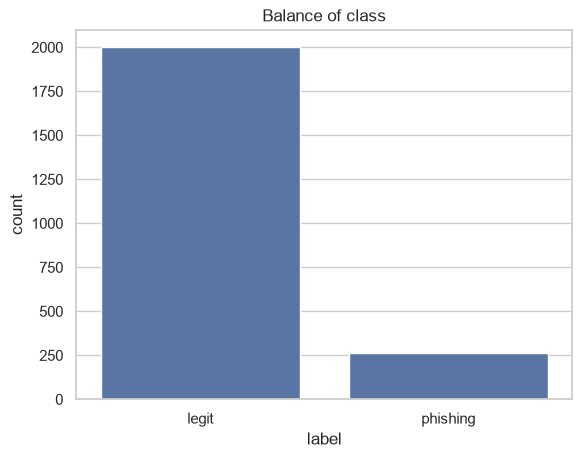

In [43]:
sns.countplot(data=df, x="label")
plt.title("Balance of class")
plt.show()

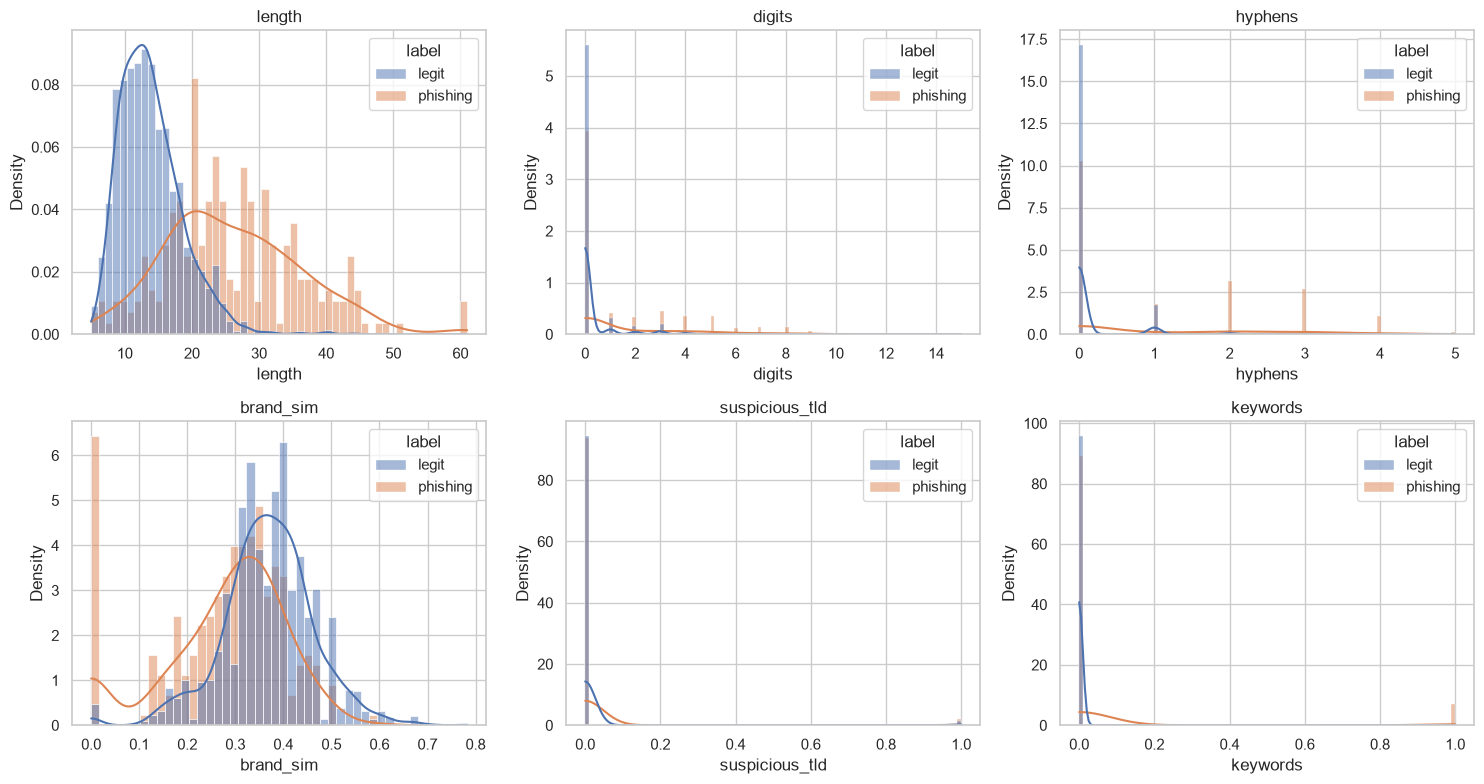

In [44]:
numeric_cols = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="label", kde=True, ax=axes[i],
                 stat="density", common_norm=False, alpha=0.5)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [45]:
df.groupby("label")[numeric_cols].mean()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords
label,,,,,,
legit,13.882500,0.294500,0.128500,0.367622,0.016000,0.002000
phishing,26.173585,1.550943,1.109434,0.277848,0.022642,0.071698


## Feature correlation heatmap

Checking how features relate to each other before moving to PCA and modeling.

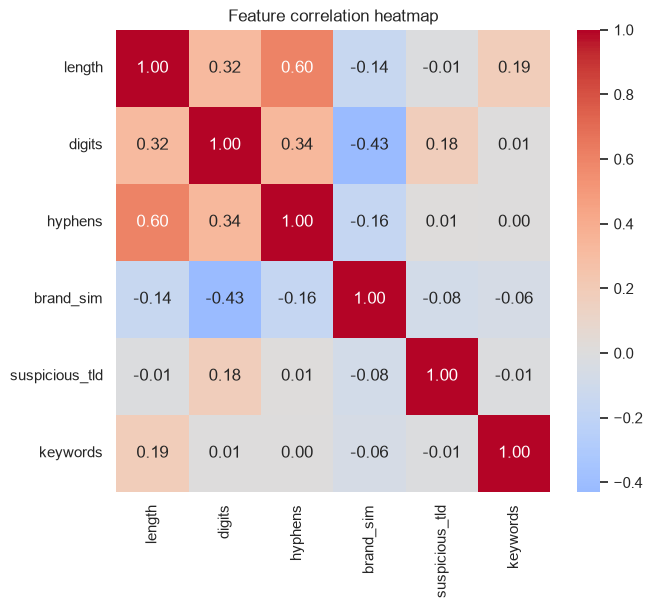

In [46]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

## EDA summary

- Dataset is imbalanced: ~15% phishing, ~85% legit (real-world proportion).
- No missing values across all 2265 rows.
- `brand_sim` and `length` show clearly different distributions between
  classes and look like the strongest individual signals.
- Sparse features (`digits`, `hyphens`, `suspicious_tld`, `keywords`) have
  low frequency in both classes, but noticeably higher averages for
  phishing domains.
- Moderate correlation (0.6) between `length` and `hyphens` -- expected,
  since longer domains have more room for hyphens. Not high enough to be
  a multicollinearity concern.
- Next steps: PCA to visualize class separability in 2D, then train and
  compare several classification models.

## 6. PCA — dimensionality reduction

Projecting all 6 features into 2 dimensions to visually check whether
phishing and legit domains form separable clusters in feature space.
This is a sanity check before training any model.

In [47]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [48]:
X = df[numeric_cols].values
y = df["label"].values

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [51]:
print(pca.explained_variance_ratio_)

[0.34065725 0.1949672 ]


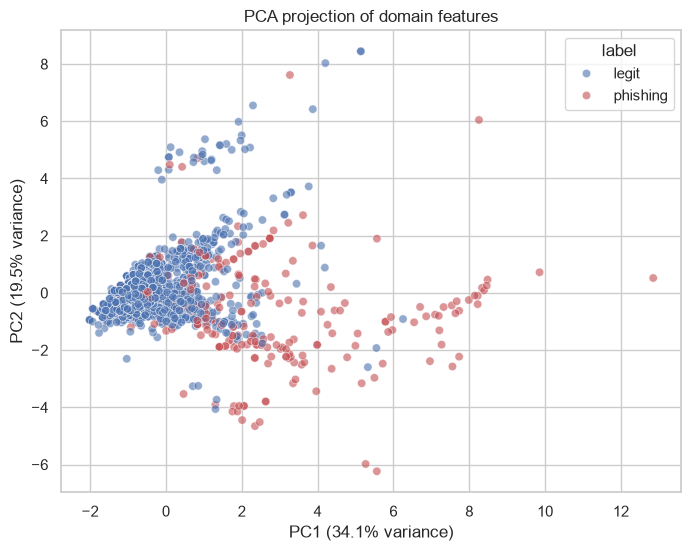

In [52]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["label"], alpha=0.6,
                 palette={"legit": "#4C72B0", "phishing": "#C44E52"})
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection of domain features")
plt.show()

## PCA conclusion

The two classes show partial separation: phishing domains tend to spread
toward higher PC1 values (longer names, higher brand similarity, more
keywords), while legit domains form a dense cluster near the origin.
There's significant overlap in the middle region, meaning the classes
aren't perfectly linearly separable in 2D -- this suggests non-linear
models (e.g. Random Forest) may outperform simpler linear ones later.

Note: PC1+PC2 only explain ~53.5% of total variance, so this 2D view
is a simplification -- the actual classifier will use all 6 features.

## 7. DBSCAN clustering

DBSCAN groups points based on density, without using the true labels.
Comparing its clusters to the actual phishing/legit split is a useful
sanity check: if DBSCAN naturally finds similar groups, it suggests the
features carry real separating signal.


In [53]:
from sklearn.cluster import DBSCAN

In [54]:
dbscan = DBSCAN(eps=0.6, min_samples=10)
clusters = dbscan.fit_predict(X_pca)

In [55]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
n_clusters

4

In [56]:
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise / len(clusters) * 100:.1f}%)")

Clusters found: 4
Noise points: 82 (3.6%)


## DBSCAN clusters vs. true labels

Comparing DBSCAN's unsupervised clusters side-by-side with the actual
phishing/legit labels to check whether the discovered structure aligns
with the real classification target.

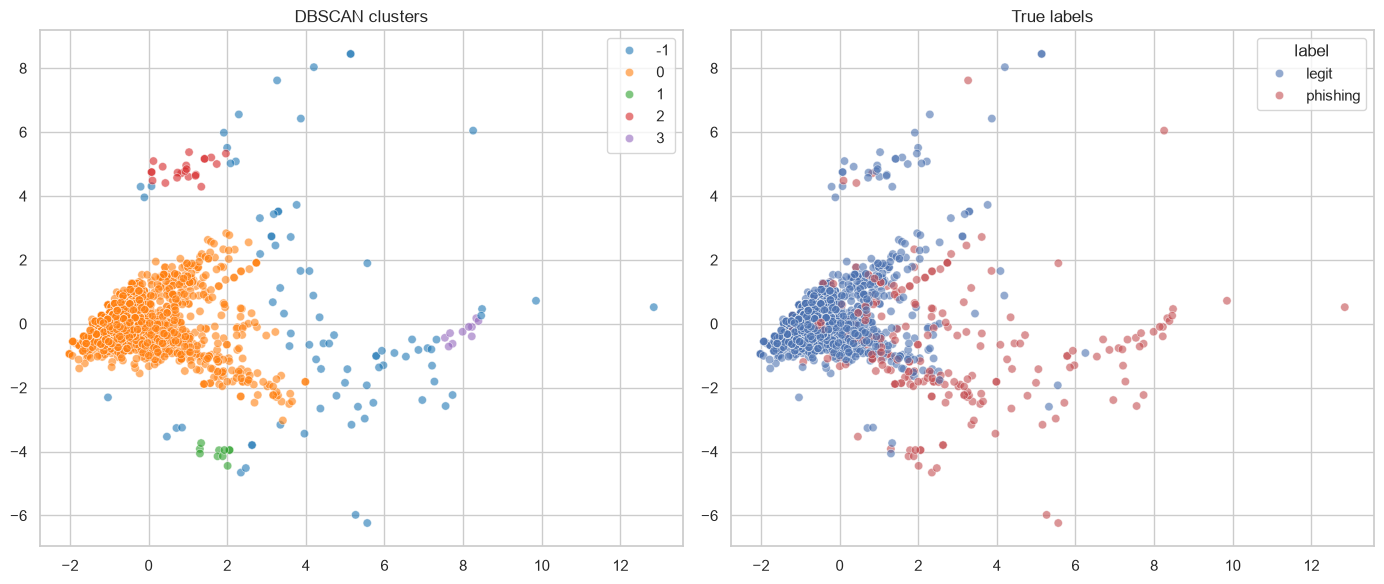

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="tab10",
                 alpha=0.6, ax=axes[0], legend="full")
axes[0].set_title("DBSCAN clusters")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["label"], alpha=0.6,
                 ax=axes[1], palette={"legit": "#4C72B0", "phishing": "#C44E52"})
axes[1].set_title("True labels")

plt.tight_layout()
plt.show()

## DBSCAN conclusion

Cluster 0 (the dense group near the origin) is overwhelmingly legit,
while clusters 1, 2, and 3 are dominated by phishing domains. This is
a strong signal: even without seeing the labels, DBSCAN found structure
that aligns well with the actual classification target. The fact that
phishing splits into multiple sub-clusters (rather than one uniform
group) suggests different phishing "styles" in the data (e.g. some rely
on brand similarity, others on long keyword-heavy names).

This supports moving forward with supervised classification models,
since the features clearly carry separating signal.